# DINOv3 Latent Space Geometric Audit: Aging & Robustness Analysis

This notebook performs a comprehensive analysis of how DINOv3 (ViT-B/16) encodes human aging and demographic features. It includes:
1. **Aging Sequence Audit**: Analyzing a specific person across multiple ages (18-100) with color normalization and noise simulations to measure trajectory consistency.
2. **External Comparison**: Projecting new images into the established aging manifold.
3. **Demographic Latent Audit (UTKFace)**: Extracting embeddings from the UTKFace dataset to visualize how age and gender are organized in 3D latent space.
4. **Interactive Visualization**: Exporting data for the TensorBoard Embedding Projector.

In [1]:
import os
import torch
import numpy as np
import glob
import matplotlib.pyplot as plt
import cv2
import kagglehub
import pandas as pd
import plotly.express as px
from PIL import Image
from tqdm import tqdm
from skimage.exposure import match_histograms
from torchvision import transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoImageProcessor, AutoModel
from torch.utils.tensorboard import SummaryWriter

# CONFIGURATION
INPUT_SIZE = 224 # Set to None to use model default (224)
MODEL_NAME = 'facebook/dinov3-vitb16-pretrain-lvd1689m'
DATA_DIR = r'k:\Trabajos\Code\copyair\data\03_processed\test_age'
REFERENCE_AGE = 18

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

k:\Trabajos\Code\copyair\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Model Setup
Loading DINOv3 model and processor.

In [2]:
print(f"Loading model: {MODEL_NAME}")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

default_size = processor.size.get('shortest_edge', processor.size.get('height', 'unknown'))
if INPUT_SIZE:
    print(f"OVERRIDING input size to: {INPUT_SIZE}x{INPUT_SIZE}")
else:
    print(f"Using model default size: {default_size}")

Loading model: facebook/dinov3-vitb16-pretrain-lvd1689m
OVERRIDING input size to: 224x224


## 2. Aging Sequence Discovery
Scanning the data folder for age-labeled images.

In [3]:
png_files = glob.glob(os.path.join(DATA_DIR, "*.png"))
age_files = {}
for f in png_files:
    try:
        age = int(os.path.basename(f).split('.')[0])
        age_files[age] = f
    except ValueError:
        continue

ages = sorted(age_files.keys())
print(f"Found ages: {ages}")

ref_age = REFERENCE_AGE if REFERENCE_AGE in age_files else ages[0]
print(f"Reference Age for color matching: {ref_age}")

Found ages: [18, 30, 50, 70, 100]
Reference Age for color matching: 18


## 3. Pre-processing: Color Normalization & Robustness Simulation
We apply histogram matching to the ref age and run multiple random noise simulations.

In [4]:
def load_cv2_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def add_gaussian_noise(image, sigma=10):
    noise = np.random.normal(0, sigma, image.shape)
    noisy_img = image.astype(np.float32) + noise
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

# SIMULATION SETTINGS
N_SIMULATIONS = 5
SIGMA_RUIDO = 20
matched_simulations = {age: [] for age in ages}

reference_img = load_cv2_image(age_files[ref_age])
print(f"Generating {N_SIMULATIONS} simulations per age with noise sigma={SIGMA_RUIDO}...")

for age in ages:
    target_img = load_cv2_image(age_files[age])
    
    # 1. Histogram Matching
    if age == ref_age:
        base_img = target_img
    else:
        base_img = match_histograms(target_img, reference_img, channel_axis=-1)
    
    # 2. Noise Simulations
    for i in range(N_SIMULATIONS):
        noisy = add_gaussian_noise(base_img, sigma=SIGMA_RUIDO)
        matched_simulations[age].append(noisy)

print("Pre-processing complete.")

Generating 5 simulations per age with noise sigma=20...
Pre-processing complete.


## 4. Embedding Extraction
Processing all 100+ images through DINOv3.

In [5]:
def get_cls_embedding_from_numpy(img_np):
    image = Image.fromarray(img_np)
    if INPUT_SIZE:
        inputs = processor(images=image, size={"height": INPUT_SIZE, "width": INPUT_SIZE}, return_tensors="pt").to(device)
    else:
        inputs = processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = cls_embedding / cls_embedding.norm(dim=-1, keepdim=True)
        
    return cls_embedding.cpu().numpy().flatten()

all_embeddings = []
all_ages_labels = []

for age in ages:
    print(f"Extracting embeddings for Age {age}...", end=" ")
    for img_np in matched_simulations[age]:
        emb = get_cls_embedding_from_numpy(img_np)
        all_embeddings.append(emb)
        all_ages_labels.append(age)
    print("Done.")

all_embeddings = np.array(all_embeddings)
all_ages_labels = np.array(all_ages_labels)

print(all_embeddings.shape, all_ages_labels.shape)

Extracting embeddings for Age 18... Done.
Extracting embeddings for Age 30... Done.
Extracting embeddings for Age 50... Done.
Extracting embeddings for Age 70... Done.
Extracting embeddings for Age 100... Done.
(25, 768) (25,)


## 5. Visualizing the Aging Manifold

In [6]:
import plotly.graph_objects as go

# 1. Aplicar PCA para 3 Componentes
pca_3d_audit = PCA(n_components=3)
embeddings_3d = pca_3d_audit.fit_transform(all_embeddings)

# 2. Calcular los Centroides en 3D (Trayectoria)
centroids_3d = []
for age in ages:
    mask = (all_ages_labels == age)
    centroids_3d.append(embeddings_3d[mask].mean(axis=0))
centroids_3d = np.array(centroids_3d)

# 3. Crear el gráfico interactivo
fig = go.Figure()

# Capa 1: Nube de puntos (simulaciones con ruido)
fig.add_trace(go.Scatter3d(
    x=embeddings_3d[:, 0], 
    y=embeddings_3d[:, 1], 
    z=embeddings_3d[:, 2],
    mode='markers',
    marker=dict(
        size=3,
        color=all_ages_labels, 
        colorscale='Viridis', 
        opacity=0.3
    ),
    name='Noise Simulations'
))

# Capa 2: Manifold (Línea roja y centroides)
fig.add_trace(go.Scatter3d(
    x=centroids_3d[:, 0], 
    y=centroids_3d[:, 1], 
    z=centroids_3d[:, 2],
    mode='lines+markers+text',
    text=[f"Edad {a}" for a in ages],
    textposition="top center",
    marker=dict(
        size=6, 
        color=ages, 
        colorscale='Viridis', 
        line=dict(width=2, color='black')
    ),
    line=dict(color='red', width=5),
    name='Age Manifold'
))

# 4. Estilizar para que coincida con tus gráficas anteriores
fig.update_layout(
    title="DINOv3 Robustness Audit: Space 3D Manifold",
    scene=dict(
        xaxis=dict(title='PC1', backgroundcolor="white", gridcolor="lightgray", showbackground=True),
        yaxis=dict(title='PC2', backgroundcolor="white", gridcolor="lightgray", showbackground=True),
        zaxis=dict(title='PC3', backgroundcolor="white", gridcolor="lightgray", showbackground=True),
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3',
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    template="plotly_white"
)

fig.show()

print(f"Varianza total explicada (3 componentes): {sum(pca_3d_audit.explained_variance_ratio_):.2%}")

import plotly.io as pio

pio.write_html(fig, "grafico_pca3d.html", include_plotlyjs="cdn")


Varianza total explicada (3 componentes): 91.10%


In [7]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(all_embeddings)

# plt.figure(figsize=(12, 9))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=all_ages_labels, 
#                       cmap='viridis', alpha=0.3, s=40, edgecolors='none')

# # Calculate Centroids
# centroids = []
# for age in ages:
#     mask = all_ages_labels == age
#     c = embeddings_2d[mask].mean(axis=0)
#     centroids.append(c)
#     plt.scatter(c[0], c[1], c=[age], cmap='viridis', s=100, edgecolors='black', linewidth=0, zorder=10)
#     plt.annotate(f"Age {age}", (c[0], c[1]), xytext=(0, 12), textcoords="offset points", ha='center', fontweight='bold')

# centroids = np.array(centroids)
# plt.plot(centroids[:, 0], centroids[:, 1], 'r--', alpha=0.4, zorder=5)

# plt.colorbar(scatter, label='Age')
# plt.title(f"DINOv3 Robustness Audit: Latent Aging Manifold\n({N_SIMULATIONS} simulations per point, Noise $\\sigma$={SIGMA_RUIDO})", fontsize=14)
# plt.grid(True, linestyle=':', alpha=0.5)
# plt.show()

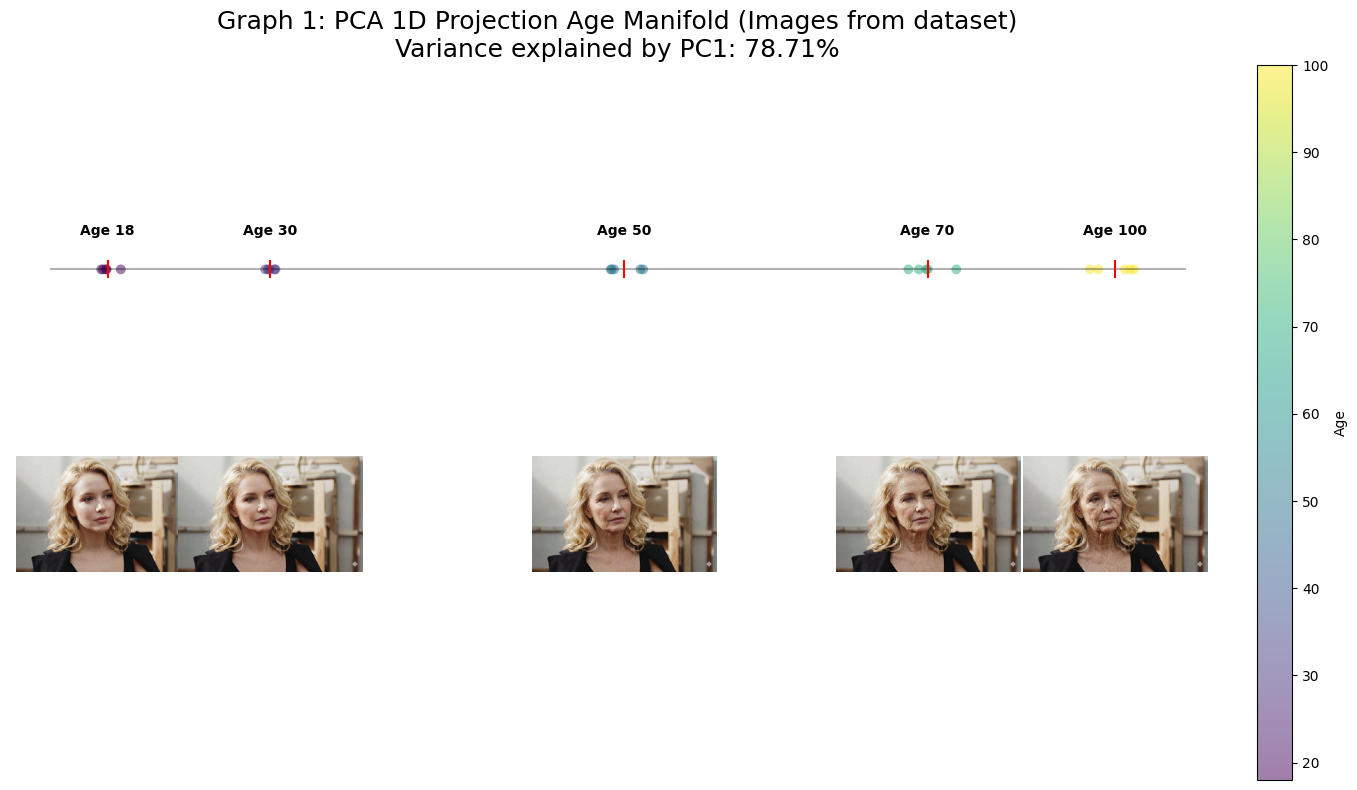

Variance explained by PC1: 78.71%


In [8]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

# 1. Apply PCA for 1 Component
pca_1d = PCA(n_components=1)
embeddings_1d = pca_1d.fit_transform(all_embeddings)

plt.figure(figsize=(15, 8)) # Aumentamos un poco el alto para las fotos

# 2. Add a little "jitter" (noise) in Y so points are more visible
jitter = np.random.uniform(-0.00, 0.00, size=len(embeddings_1d))

# 3. Plot individual points
scatter = plt.scatter(embeddings_1d[:, 0], jitter, c=all_ages_labels, 
                      cmap='viridis', alpha=0.5, s=50, edgecolors='none')

# 4. Calculate and plot averages + IMAGES
for age in ages:
    mask = all_ages_labels == age
    c_1d = embeddings_1d[mask].mean()
    
    # Draw average point at Y=0
    plt.scatter(c_1d, 0, color='red', s=150, marker='|', zorder=10)
    
    # Label superior (Edad)
    plt.annotate(f"Age {age}", (c_1d, 0), xytext=(0, 25), 
                 textcoords="offset points", ha='center', fontsize=10,
                 fontweight='bold', rotation=0)

    # --- NUEVA SECCIÓN: AGREGAR IMÁGENES ---
    if age in matched_simulations and len(matched_simulations[age]) > 0:
        # Tomamos la primera simulación de cada edad como representante
        img_np = matched_simulations[age][0] 
        # Redimensionamos la miniatura para que no tape el gráfico
        img_thumb = Image.fromarray(img_np).resize(tuple(int(x * 265 / max(img_np.shape[1], img_np.shape[0])) for x in img_np.shape[1::-1]), Image.LANCZOS)

        
        imagebox = OffsetImage(img_thumb, zoom=0.5) # Ajusta el zoom si quieres fotos más grandes
        # Colocamos la imagen en (c_1d, -0.15) para que quede debajo de la línea
        ab = AnnotationBbox(imagebox, (c_1d, -0.12), frameon=False,
                            bboxprops=dict(edgecolor='gray', alpha=0.5))
        plt.gca().add_artist(ab)

# 5. Draw baseline
plt.axhline(0, color='black', linestyle='-', alpha=0.3, zorder=1)

# Ajustes estéticos finales
plt.colorbar(scatter, label='Age', pad=0.05)
plt.title(f"Graph 1: PCA 1D Projection Age Manifold (Images from dataset)\nVariance explained by PC1: {pca_1d.explained_variance_ratio_[0]:.2%}", fontsize=18)
#plt.xlabel("Principal Component 1 (Latent Space Direction)")

# Ajustamos los límites de Y para que quepan las fotos abajo
plt.ylim(-0.25, 0.1)
plt.xticks([])
plt.yticks([]) 
plt.grid(axis='x', linestyle=':', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca_1d.explained_variance_ratio_[0]:.2%}")

## 6. Batch Test Folder Analysis
Projecting external images into the established manifold.

In [9]:
# test_dir = r'k:\Trabajos\Code\copyair\data\03_processed\test_age\test'
# test_files = glob.glob(os.path.join(test_dir, "*.[jJ][pP]*[gG]")) + glob.glob(os.path.join(test_dir, "*.[pP][nN][gG]"))
# test_filenames = [os.path.basename(f) for f in test_files]

# # Create PCA 2D trained with the audit sequence
# pca_2d = PCA(n_components=2)
# embeddings_2d = pca_2d.fit_transform(all_embeddings)   # <-- Fit PCA here
# centroids = np.array([embeddings_2d[all_ages_labels == age].mean(axis=0) for age in ages])

# if test_files:
#     # Extract and transform test embeddings
#     test_embeddings = []
#     for path in test_files:
#         img = load_cv2_image(path)
#         emb = get_cls_embedding_from_numpy(img)
#         test_embeddings.append(emb)
        
#     test_2d = pca_2d.transform(np.array(test_embeddings))
    
#     plt.figure(figsize=(12, 9))
    
#     # 1. Background: Audit sequence points (low opacity)
#     scatter_bg = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=all_ages_labels, 
#                              cmap='viridis', alpha=0.15, s=40, edgecolors='none')
    
#     # 2. Trajectory line of the original sequence
#     plt.plot(centroids[:, 0], centroids[:, 1], color='black', linestyle='--', linewidth=2, alpha=0.3, zorder=5)
    
#     # 3. Projection of external subjects (large circles)
#     cmap_test = plt.cm.viridis
#     for i in range(len(test_2d)):
#         color = cmap_test(i / max(1, len(test_2d)-1))
#         # Main point
#         plt.scatter(test_2d[i,0], test_2d[i,1], color=color, marker='o', s=300, 
#                     edgecolors='black', linewidth=0, label=test_filenames[i], zorder=25)
        
#         # Stylized annotation
#         plt.annotate(test_filenames[i], (test_2d[i,0], test_2d[i,1]), xytext=(0, -25), 
#                      textcoords="offset points", ha='center', fontsize=9, fontweight='bold',
#                      bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='gray'))

#     plt.title("Graph 3: 2D Audit Projection (PC1 vs PC2): External Subjects in Sequence Manifold", fontsize=14)
#     plt.xlabel("Principal Component 1")
#     plt.ylabel("Principal Component 2")
#     plt.legend(title="Test Files", bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.grid(True, linestyle=':', alpha=0.6)
#     plt.tight_layout()
#     plt.show()
    
#     print("\n--- 2D Proximity Report ---")
#     for i in range(len(test_2d)):
#         dist = np.linalg.norm(centroids - test_2d[i], axis=1)
#         closest_age = ages[np.argmin(dist)]
#         print(f"[{test_filenames[i]:<20}] -> closest to Sequence Age {closest_age}")


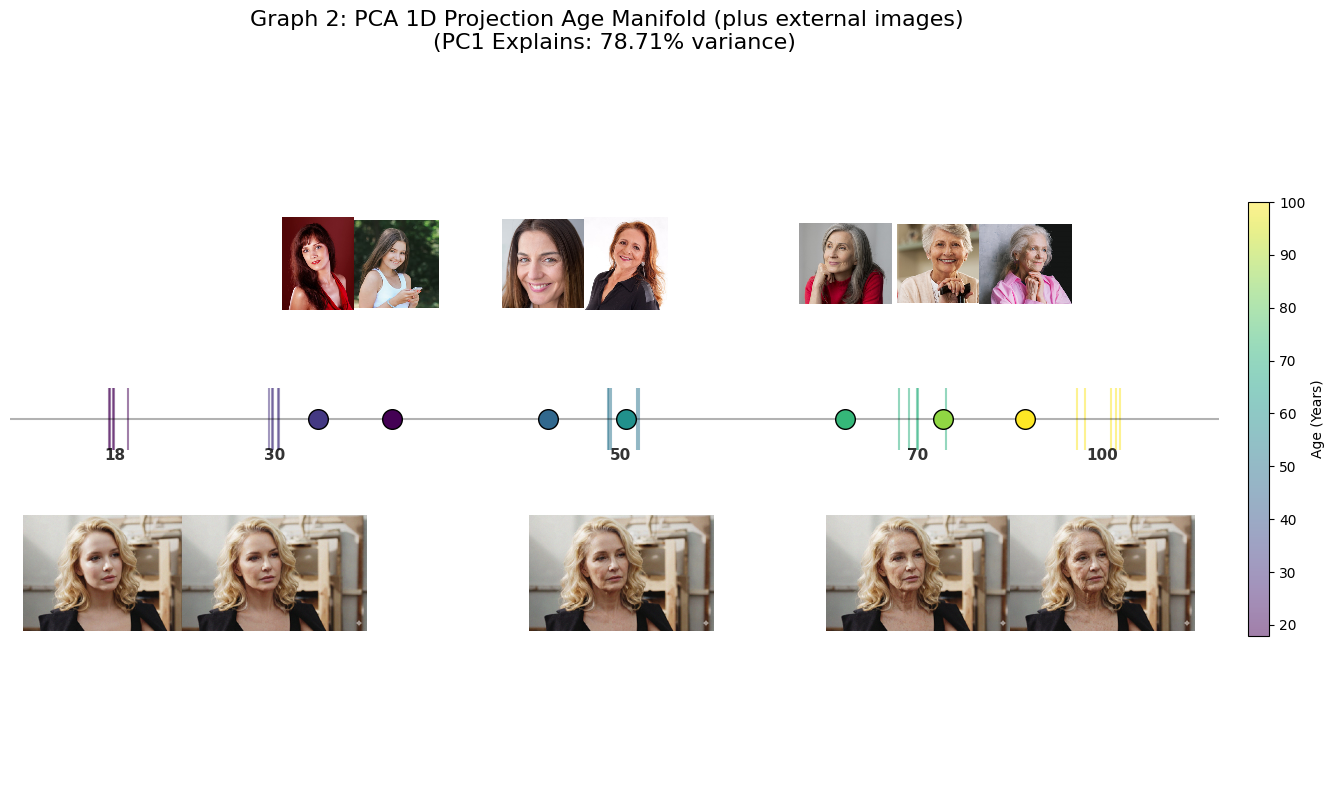


--- 1D Proximity Report ---
[12.jpg              ] -> Closes to Seq Age 30
[20.jpg              ] -> Closes to Seq Age 30
[30.jpg              ] -> Closes to Seq Age 50
[55.jpg              ] -> Closes to Seq Age 50
[65.jpg              ] -> Closes to Seq Age 70
[75.jpeg             ] -> Closes to Seq Age 70
[95.jpg              ] -> Closes to Seq Age 100


In [10]:
test_dir = r'k:\Trabajos\Code\copyair\data\03_processed\test_age\test'
test_files = glob.glob(os.path.join(test_dir, "*.[jJ][pP]*[gG]")) + glob.glob(os.path.join(test_dir, "*.[pP][nN][gG]"))
test_filenames = [os.path.basename(f) for f in test_files]

if test_files:
    # 1. Entrenar PCA 1D con la secuencia de auditoría
    pca_1d_test = PCA(n_components=1)
    embeddings_1d_audit = pca_1d_test.fit_transform(all_embeddings).flatten()
    
    # 2. Extraer y transformar embeddings de test (Cargando imágenes para las miniaturas superiores)
    test_embeddings = []
    test_imgs_loaded = []
    for path in test_files:
        img = load_cv2_image(path)
        test_imgs_loaded.append(img)
        emb = get_cls_embedding_from_numpy(img)
        test_embeddings.append(emb)
    
    test_1d = pca_1d_test.transform(np.array(test_embeddings)).flatten()
    
    # 3. Calcular centroides 1D
    centroids_1d = []
    for age in ages:
        mask = (all_ages_labels == age)
        centroids_1d.append(embeddings_1d_audit[mask].mean())
    centroids_1d = np.array(centroids_1d)

    # 4. Graficar
    plt.figure(figsize=(15, 8)) # Más espacio vertical para el doble nivel de fotos
    
    # Fondo: Degradado de Auditoría (Barras verticales)
    scatter_bg = plt.scatter(embeddings_1d_audit, np.zeros_like(embeddings_1d_audit), 
                             c=all_ages_labels, cmap='viridis', alpha=0.5, s=2000, marker='|')

    # --- ABAJO: IMÁGENES DE AUDITORÍA (REFERENCIA) ---
    for i, age in enumerate(ages):
        if age in matched_simulations and len(matched_simulations[age]) > 0:
            img_np = matched_simulations[age][0]
            # Redimensionado consistente
            new_size = (int(img_np.shape[1] * 265 / max(img_np.shape)), int(img_np.shape[0] * 265 / max(img_np.shape)))
            img_thumb = Image.fromarray(img_np).resize(new_size, Image.LANCZOS)
            
            imagebox = OffsetImage(img_thumb, zoom=0.5)
            ab = AnnotationBbox(imagebox, (centroids_1d[i], -0.15), frameon=False)
            plt.gca().add_artist(ab)
            
            # Etiqueta de edad abajo del todo
            plt.annotate(f"{age}", (centroids_1d[i], -0.04), ha='center', fontsize=11, fontweight='bold', alpha=0.8)

    # --- ARRIBA: IMÁGENES DE TEST (NUEVOS SUJETOS) ---
    cmap_test = plt.cm.viridis 
    for i in range(len(test_1d)):
        color = cmap_test(i / max(1, len(test_1d)-1))
        
        # Miniatura del Sujeto arriba
        img_np = test_imgs_loaded[i]
        new_size = (int(img_np.shape[1] * 265 / max(img_np.shape)), int(img_np.shape[0] * 265 / max(img_np.shape)))
        img_thumb = Image.fromarray(img_np).resize(new_size, Image.LANCZOS)
        
        imagebox = OffsetImage(img_thumb, zoom=0.25)
        #y_offset = 0.16 if i % 2 == 0 else 0.1
        #y_offset = 0.05 + 0.04 * i
        ab = AnnotationBbox(imagebox, (test_1d[i], 0.15), frameon=False)
        plt.gca().add_artist(ab)

        # Punto circular en la línea y etiqueta superior
        plt.scatter(test_1d[i], 0, color=color, marker='o', s=200, edgecolors='black', zorder=30)
        #plt.annotate(test_filenames[i], (test_1d[i], 0.25), ha='center', fontsize=9, 
                     #fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec=color))

    # Estética Final
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
    plt.title(f"Graph 2: PCA 1D Projection Age Manifold (plus external images)  \n(PC1 Explains: {pca_1d_test.explained_variance_ratio_[0]:.2%} variance)", fontsize=16)
    
    # Barra de color integrada
    plt.colorbar(scatter_bg, label='Age (Years)', pad=0.02, shrink=0.6)

    # Configuración de límites y limpieza de ejes
    plt.ylim(-0.35, 0.35)
    plt.xlim(embeddings_1d_audit.min() - 0.075, embeddings_1d_audit.max() + 0.075)
    plt.xticks([])
    plt.yticks([])
    
    ax = plt.gca()
    for spine in ax.spines.values(): spine.set_visible(False)

    plt.tight_layout()
    plt.show()
    
    print("\n--- 1D Proximity Report ---")
    for i in range(len(test_1d)):
        dist = np.abs(centroids_1d - test_1d[i])
        print(f"[{test_filenames[i]:<20}] -> Closes to Seq Age {ages[np.argmin(dist)]}")

## 7. Large Scale Demographic Audit (UTKFace)
Analyzing organization of Age and Gender using a larger dataset sample.

In [11]:
# 1. Download and find images
utk_path = kagglehub.dataset_download("yuulind/utk-cleaned")
csv_path = glob.glob(os.path.join(utk_path, "*.csv"))[0]
df_full = pd.read_csv(csv_path)

# Find image folder
img_folder = None
for root, dirs, files in os.walk(utk_path):
    if any(f.endswith('.jpg') for f in files):
        img_folder = root
        break

# --- FILTRAR SOLO MUJERES Y LUEGO TOMAR MUESTRA ---
df_females = df_full[df_full['gender'] == 'F'].copy()

X_SAMPLES = 1000 # Aumentado para que el promedio/manifold sea más representativo
df_utk = df_females.sample(n=min(X_SAMPLES, len(df_females)), random_state=42).copy()
df_utk['full_path'] = df_utk['img_name'].apply(lambda x: os.path.join(img_folder, x))

# 2. Extract Embeddings
utk_embeddings = []
print(f"Extracting UTKFace embeddings (Only Females, N={len(df_utk)})...")
for p in tqdm(df_utk['full_path']):
    try:
        img = Image.open(p).convert('RGB').resize((224, 224))
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**inputs)
            emb = out.last_hidden_state[:, 0, :]
            emb = emb / emb.norm(dim=-1, keepdim=True)
            utk_embeddings.append(emb.cpu().numpy().flatten())
    except:
        utk_embeddings.append(np.zeros(768))

df_utk['embedding'] = list(np.array(utk_embeddings))

Extracting UTKFace embeddings (Only Females, N=1000)...


100%|██████████| 1000/1000 [03:59<00:00,  4.17it/s]


## 8. 3D Latent Interactive Visualization (Plotly)
Age as color, Gender as symbol.

In [12]:
# # Crear DataFrame de la secuencia de auditoría
# df_audit = pd.DataFrame({
#     'age': all_ages_labels,
#     'embedding': list(all_embeddings)
# })

# # Agregar etiquetas para identificar el origen (opcional pero útil)
# df_audit['gender'] = 'Audit'
# df_audit['full_path'] = 'Sequence_Audit'

# # Concatenar con el dataset de UTKFace
# df_utk_all = pd.concat([df_utk, df_audit], ignore_index=True)

# print(f"Dataset actualizado: {len(df_utk)} registros totales.")

Subjects per age group:
age_group
20-30    600
30-40    223
40-50     90
50-60     87
Name: count, dtype: int64


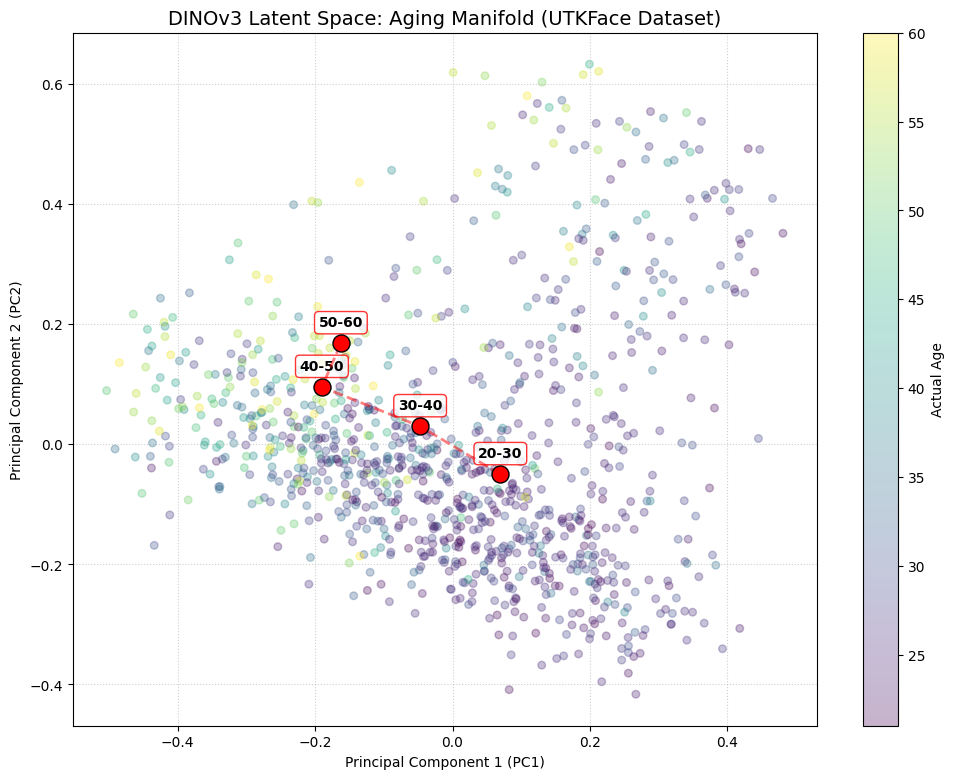

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# 1. Setting up 10-year bins (focusing on where the UTKFace data is densest)
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']

df_utk_all = df_utk.copy()

# Grouping by age brackets
df_utk_all['age_group'] = pd.cut(df_utk_all['age'], bins=bins, labels=labels, include_lowest=True)

# Quick check on the distribution... just to be sure we have enough samples per bin
print("Subjects per age group:")
print(df_utk_all['age_group'].value_counts())

# 2. 2D PCA projection
# We take the DINOv3 high-dimensional embeddings and squash them into 2D to see the structure
all_embs = np.array(df_utk_all['embedding'].tolist())
pca_2d = PCA(n_components=2)
vis_2d = pca_2d.fit_transform(all_embs)
df_utk_all['pc1'], df_utk_all['pc2'] = vis_2d[:, 0], vis_2d[:, 1]

# 3. Finding the "Age Centroids"
# We calculate the mean position of each group in the latent space to trace the trajectory
centroids_df = df_utk_all.groupby('age_group', observed=True)[['pc1', 'pc2']].mean().reset_index()
centroids_df = centroids_df.dropna(subset=['pc1', 'pc2'])

# 4. Plotting the Aging Manifold
plt.figure(figsize=(12, 9))

# The background: individual samples from UTKFace
scatter = plt.scatter(df_utk_all['pc1'], df_utk_all['pc2'], c=df_utk_all['age'], 
                      cmap='viridis', alpha=0.3, s=30)

# The Trajectory: connecting the dots between age groups
if len(centroids_df) > 1:
    plt.plot(centroids_df['pc1'], centroids_df['pc2'], color='red', linestyle='--', 
             linewidth=2, alpha=0.5, zorder=5)

# Marking the average point for each decade
for i, row in centroids_df.iterrows():
    plt.scatter(row['pc1'], row['pc2'], color='red', marker='o', s=150, edgecolors='black', zorder=10)
    plt.annotate(row['age_group'], (row['pc1'], row['pc2']), xytext=(0, 12), 
                 textcoords="offset points", ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='red'))

plt.colorbar(scatter, label='Actual Age')
plt.title(f"DINOv3 Latent Space: Aging Manifold (UTKFace Dataset)", fontsize=14)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

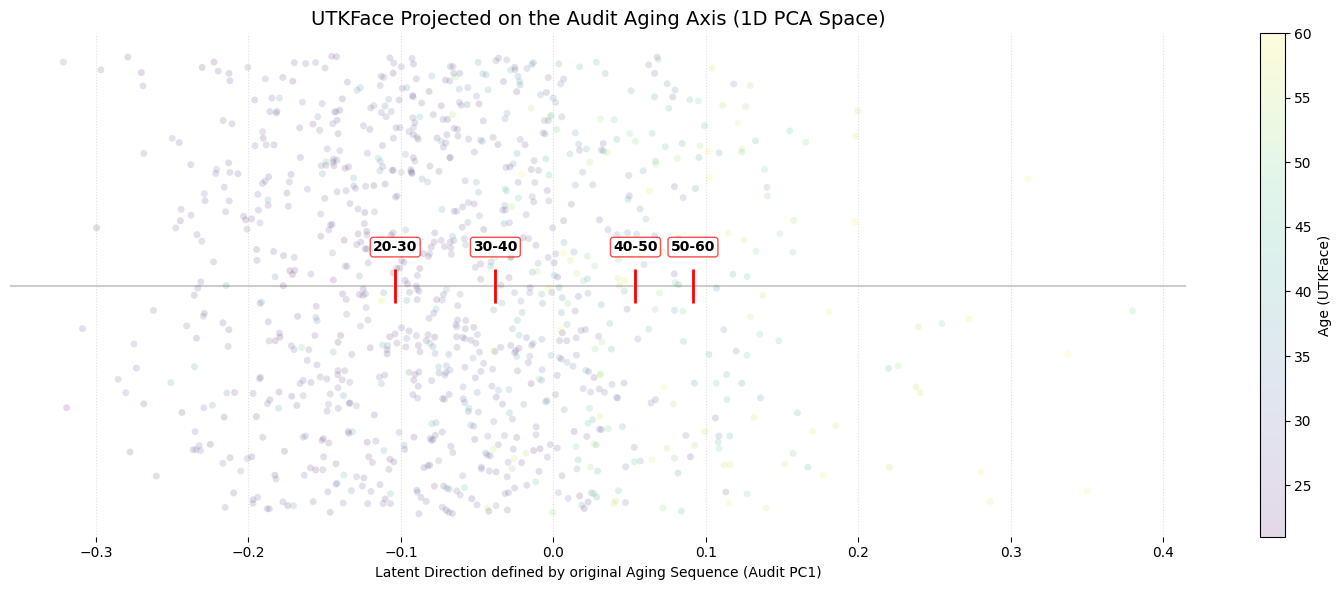

Nota: Los datos se han proyectado usando el componente que explica el 78.7% de la varianza original.


In [18]:
# 1. Configuración de rangos (Filtramos donde hay densidad de datos)
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']
df_utk_1d = df_utk.copy()
df_utk_1d['age_group'] = pd.cut(df_utk_1d['age'], bins=bins, labels=labels, include_lowest=True)

# 2. PROYECCIÓN EN EL ESPACIO 1D EXISTENTE
# Usamos .transform() (NO fit_transform) para usar exactamente el mismo eje de la auditoría
utk_embs_array = np.array(df_utk_1d['embedding'].tolist())
df_utk_1d['pc1_audit'] = pca_1d_test.transform(utk_embs_array).flatten()

# 3. Calcular Centroides en esa dimensión
centroids_1d = df_utk_1d.groupby('age_group', observed=True)['pc1_audit'].mean().reset_index()

# 4. Graficar con la estética 1D (Minimalista con Jitter)
plt.figure(figsize=(15, 6))

# Jitter para que los puntos UTKFace no se solapen
jitter = np.random.uniform(-0.01, 0.01, size=len(df_utk_1d))

# Fondo: Sujetos UTKFace proyectados en el eje de auditoría
scatter = plt.scatter(df_utk_1d['pc1_audit'], jitter, c=df_utk_1d['age'], 
                      cmap='viridis', alpha=0.15, s=25, edgecolors='none')

# Dibujar Centroides (Promedios por década)
for i, row in centroids_1d.iterrows():
    if not np.isnan(row['pc1_audit']):
        # Marcador de promedio
        plt.scatter(row['pc1_audit'], 0, color='red', marker='|', s=600, zorder=10, linewidth=2)
        # Etiqueta
        plt.annotate(row['age_group'], (row['pc1_audit'], 0), xytext=(0, 25), 
                     textcoords="offset points", ha='center', fontsize=10, 
                     fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='red'))

# Estética de línea de tiempo
plt.axhline(0, color='black', alpha=0.2, zorder=1)
plt.colorbar(scatter, label='Age (UTKFace)')
plt.title("UTKFace Projected on the Audit Aging Axis (1D PCA Space)", fontsize=14)
plt.xlabel("Latent Direction defined by original Aging Sequence (Audit PC1)")

# Limpiar bordes
plt.yticks([]) 
ax = plt.gca()
for spine in ax.spines.values(): spine.set_visible(False)
plt.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Nota: Los datos se han proyectado usando el componente que explica el {pca_1d_test.explained_variance_ratio_[0]:.1%} de la varianza original.")

## 9. TensorBoard Embedding Projector Export
This creates the log files and sprite sheet for the projector.

In [14]:
log_dir = "logs/utk_projector"
if not os.path.exists(log_dir): os.makedirs(log_dir)
writer = SummaryWriter(log_dir)

emb_tensor = torch.tensor(np.array(df_utk_all['embedding'].tolist()))
meta = [f"Age:{r['age']}" for _, r in df_utk_all.iterrows()]

print("Generating thumbnails for projector...")
thumbs = []
for p in df_utk_all['full_path']:
    img = Image.open(p).convert('RGB').resize((64, 64))
    thumbs.append(transforms.ToTensor()(img))
label_imgs = torch.stack(thumbs)

writer.add_embedding(emb_tensor, metadata=meta, label_img=label_imgs, tag="UTKFace_Audit")
writer.close()

print(f"Files saved to {log_dir}. Run in terminal:")
print(f"set PYTHONNOUSERSITE=1 && python -m tensorboard.main --logdir={os.path.abspath(log_dir)}")

Generating thumbnails for projector...
Files saved to logs/utk_projector. Run in terminal:
set PYTHONNOUSERSITE=1 && python -m tensorboard.main --logdir=k:\Trabajos\Code\copyair\notebooks\logs\utk_projector


## 10. 2D PCA & Age Manifold Analysis (TensorBoard)
This cell calculates age-group centroids from UTKFace and adds the original aging sequence images to visualize the aging trajectory/manifold in TensorBoard.

In [15]:
# import torch
# import os
# import numpy as np
# from PIL import Image
# from torch.utils.tensorboard import SummaryWriter
# from torchvision import transforms

# # Listas para recolectar todo sincronizado
# final_embeddings = []
# final_metadata = []
# final_thumbs = []

# # 1. Promedios por rangos (UTKFace)
# age_bins = [(0, 20), (20, 30), (30, 40), (40, 50), (50, 60), (70, 120)]
# print("Procesando promedios por grupo...")
# for start, end in age_bins:
#     bin_df = df_full[(df_full['age'] >= start) & (df_full['age'] < end)]
#     if len(bin_df) > 0:
#         sample_df = bin_df.sample(n=min(len(bin_df), 50), random_state=42)
#         temp_embs = []
#         for _, row in sample_df.iterrows():
#             p = os.path.join(img_folder, row['img_name'])
#             try:
#                 img = Image.open(p).convert('RGB').resize((224, 224))
#                 inputs = processor(images=img, return_tensors="pt").to(device)
#                 with torch.no_grad():
#                     out = model(**inputs)
#                     emb = out.last_hidden_state[:, 0, :]
#                     emb = emb / emb.norm(dim=-1, keepdim=True)
#                     temp_embs.append(emb.cpu().numpy().flatten())
#             except: continue
        
#         if temp_embs:
#             avg_emb = np.mean(temp_embs, axis=0)
#             final_embeddings.append(avg_emb / np.linalg.norm(avg_emb))
#             final_metadata.append([f"AVG_{start}-{end}", "Bin_Average"]) # Dos columnas para evitar error de header
#             # Imagen representativa
#             rep_p = os.path.join(img_folder, sample_df.iloc[0]['img_name'])
#             final_thumbs.append(transforms.ToTensor()(Image.open(rep_p).convert('RGB').resize((64, 64))))


# # 3. Muestras individuales de UTKFace
# print("Procesando algunas muestras individuales...")
# for _, r in df_utk_all.head(50).iterrows(): # Tomamos 50 para no saturar
#     p = r.get('full_path')
#     if p and os.path.exists(p):
#         try:
#             final_embeddings.append(r['embedding'])
#             final_metadata.append([f"UTK_{r['age']}", f"Individual_{r['gender']}"])
#             final_thumbs.append(transforms.ToTensor()(Image.open(p).convert('RGB').resize((64, 64))))
#         except: continue

# # --- GUARDAR CON ENCABEZADO ---
# log_dir_final = "logs/aging_manifold_fixed"
# if not os.path.exists(log_dir_final): os.makedirs(log_dir_final)
# writer = SummaryWriter(log_dir_final)

# # Convertir a tensores
# emb_tensor = torch.tensor(np.array(final_embeddings))
# label_imgs = torch.stack(final_thumbs)

# # add_embedding con metadatos de múltiples columnas (esto crea un header automáticamente)
# writer.add_embedding(
#     emb_tensor, 
#     metadata=final_metadata, 
#     metadata_header=["Label", "Source"], # <-- Esto soluciona el error de "Single column"
#     label_img=label_imgs, 
#     tag="Aging_Manifold_Audit"
# )
# writer.close()

# print(f"\nSincronización exitosa: {len(final_embeddings)} puntos creados.")
# print(f"Comando: set PYTHONNOUSERSITE=1 && python -m tensorboard.main --logdir={os.path.abspath(log_dir_final)}")